<a href="https://colab.research.google.com/github/Chaotic-Legend/CMP-415-Codes/blob/main/Homework%20%234%3A%20Logistic%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework #4: Logistic Regression
#### CMP 415: Machine Learning - Isaac D. Hoyos

For this homework assignment, you will analyze a dataset that includes students' exam scores and their admission status to a program. Please complete the following tasks to build a logistic regression model to predict future admissions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
url = "https://raw.githubusercontent.com/ch00226855/CMP414765Fall2022/main/data/ExamScores.txt"
data = pd.read_csv(url, names=["Exam1", "Exam2", "Admitted"])
print("Shape:", data.shape)
data.head()

Shape: (100, 3)


,Exam1,Exam2,Admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


(1) Split the data set into `data_train` (80%) and `data_test` (20%).

In [3]:
from sklearn.model_selection import train_test_split
# The feature variables are stored in X, and the target variable is stored in y.
X = data[["Exam1", "Exam2"]]
y = data["Admitted"]

# The dataset is split into 80% training data and 20% testing data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# The training and testing sets are combined into dataframes for convenience.
data_train = pd.concat([X_train, y_train], axis=1)
data_test = pd.concat([X_test, y_test], axis=1)

# Print the dataset sizes to confirm the split.
print("Train Size:", data_train.shape)
print("\nTest Size:", data_test.shape)

Train Size: (80, 3)

Test Size: (20, 3)


(2) Create a scatter plot for `data_train`. Use different colors to distinguish admitted students and non-admitted students.

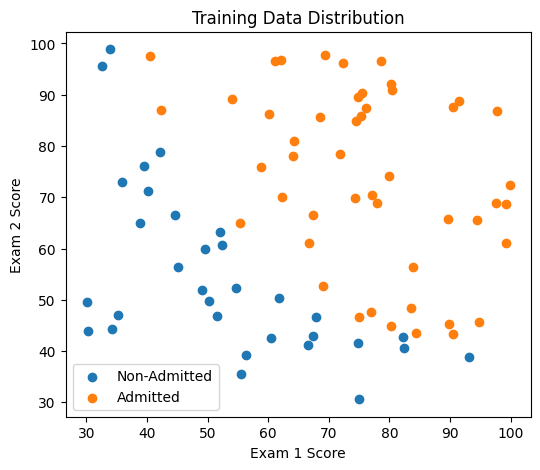

In [4]:
# The training data is separated into two groups based on admission status.
admitted = data_train[data_train["Admitted"] == 1]
not_admitted = data_train[data_train["Admitted"] == 0]

plt.figure(figsize=(6,5))

# Students who were non-admitted are plotted as one group.
plt.scatter(not_admitted["Exam1"], not_admitted["Exam2"], label="Non-Admitted")

# Students who were admitted are plotted as another group.
plt.scatter(admitted["Exam1"], admitted["Exam2"], label="Admitted")

# Labels and title are added to clearly describe the axes and the plot.
plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.title("Training Data Distribution")
plt.legend()
plt.show()

(3) Use the `LogisticRegression` class from `sklearn` to train a logistic regression model on the training set.

In [5]:
from sklearn.linear_model import LogisticRegression
# A LogisticRegression model object is created using scikit-learn.
model = LogisticRegression()

# The model is trained using the training feature data and the admission labels.
model.fit(X_train, y_train)

LogisticRegression()

(4) Visualize the decision boundary of the model.

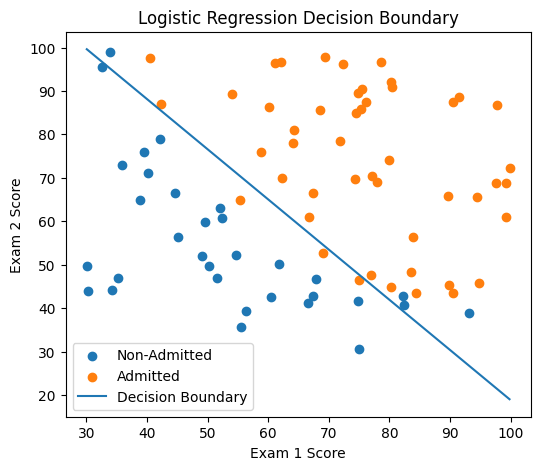

In [6]:
import numpy as np
plt.figure(figsize=(6,5))

# The training data points are plotted again to show the decision boundary.
plt.scatter(X_train[y_train==0]["Exam1"], X_train[y_train==0]["Exam2"], label="Non-Admitted")
plt.scatter(X_train[y_train==1]["Exam1"], X_train[y_train==1]["Exam2"], label="Admitted")

# Compute the decision boundary from the model parameters.
x_values = np.array([X["Exam1"].min(), X["Exam1"].max()])
y_values = -(model.coef_[0][0] * x_values + model.intercept_) / model.coef_[0][1]

# The computed decision boundary is plotted on top of the training data.
plt.plot(x_values, y_values, label="Decision Boundary")

# Axis labels and legend are added for clarity.
plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

(5) Calculate the accuracy, precision, and recall on the test set.

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Predict admission results for the test data.
y_pred = model.predict(X_test)

# Calculate evaluation metrics.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Print the model performance.
print("Accuracy:", accuracy)
print("\nPrecision:", precision)
print("\nRecall:", recall)

Accuracy: 0.8

Precision: 0.9

Recall: 0.75


(6) (Optional for Undergraduates) Modify the visualization in (4) to show how the model's output changes across the range of input exam scores.

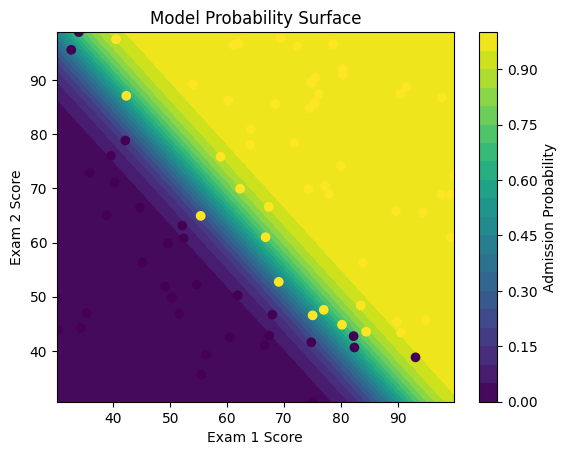

In [8]:
# Create a grid of possible exam scores.
xx, yy = np.meshgrid(
    np.linspace(X["Exam1"].min(), X["Exam1"].max(), 100),
    np.linspace(X["Exam2"].min(), X["Exam2"].max(), 100))

# Predict admission probabilities for the grid.
grid = np.c_[xx.ravel(), yy.ravel()]
grid_df = pd.DataFrame(grid, columns=["Exam1", "Exam2"])
probs = model.predict_proba(grid_df)[:,1].reshape(xx.shape)

# Plot the probability surface.
plt.contourf(xx, yy, probs, levels=20)
plt.colorbar(label="Admission Probability")

# Overlay the training data.
plt.scatter(X_train["Exam1"], X_train["Exam2"], c=y_train)
plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.title("Model Probability Surface")
plt.show()